In [1]:
import os
import sys
import torch
import json
import plotly.express as px
from transformer_lens import utils
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../scripts")
from error_eval import *
from plots import *

In [2]:
cwd = os.getcwd()
cwd = cwd.split("notebooks")[0]
print(cwd)

/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/


In [3]:
directory = "/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/results/feature_extrapolation/gpt2_resid_pre/"
model_id = "uiwt81f1"
df = pd.read_csv(directory + "e2e_ahxwn90o_feature_alive_layer_6_seed_23_pos_all.csv")
df_old = pd.read_csv(directory + "e2e_ahxwn90o_layer_6_seed_23_batchsize_1_pos_all.csv")
# df = df[df["position"] != 0]


In [9]:
df_old = df_old.drop(["alive_dict_elements"], axis = 1)

In [10]:
mean_df = pd.DataFrame(df.mean(axis=0)).T
mean_df_old = pd.DataFrame(df_old.mean(axis=0)).T

In [11]:
mean_df

,token,position,loss,length_1_loss,length_1_kl,length_1_blocks.11.hook_resid_post_L2,length_3_loss,length_3_kl,length_3_blocks.11.hook_resid_post_L2,length_5_loss,...,length_91_loss,length_91_kl,length_91_blocks.11.hook_resid_post_L2,sae_l0,sae_l1,reconstruction_error,norm,sae_norm,cos,alive_dict_elements
0,4738.867746,63.0,3.557865,3.558122,0.000182,2.426402,3.559746,0.001693,7.369665,3.563089,...,7.321061,3.783854,244.794526,9.940678,93.285198,36.059806,102.278209,82.296995,0.900423,3942.0


In [15]:
mean_df_old[["alive_feature_length_91_loss", "alive_feature_length_91_kl"]]

,alive_feature_length_91_loss,alive_feature_length_91_kl
0,7.323863,3.787168


In [3]:
from e2e_sae.scripts.analysis.utils import create_run_df, get_df_gpt2
df = get_df_gpt2()

performance_df = df.copy()

#get models that were used in the performance plot of the paper
performance_df = df.loc[(df["ratio"] == 60) & (df["seed"] == 0) & (df["n_samples"] == 400_000)]

# Ignore specialised runs
performance_df = performance_df.loc[
    ~performance_df["name"].str.contains("seed-comparison")
    & ~performance_df["name"].str.contains("lr-comparison")
    & ~performance_df["name"].str.contains("lower-downstream")
    & -performance_df["name"].str.contains("e2e-local")
    & ~performance_df["name"].str.contains("recon-all")
    & ~performance_df["name"].str.contains("misc_")]

columns_list = ["id", "sae_pos", "run_type", "layer", "L0", "CELossIncrease", "alive_dict_elements"]
df_local = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "local")].sort_values("L0")
df_e2e = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "e2e")].sort_values("L0")
df_downstream = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "downstream")].sort_values("L0")

Processing runs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 299/299 [00:10<00:00, 28.75it/s]


In [101]:
performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "downstream")].sort_values("L0")[["L0"]]

,L0
115,31.445117
215,36.789443
216,46.487998
219,58.823125
220,90.038452
221,131.283403
222,472.623281


# Plot Across different L0s

## Functions

In [121]:
def read_file(model_id, nrows = None):
    data_path = directory + f'/e2e_{model_id}_layer_6_seed_23_batchsize_1_pos_{pos}.csv'

    if nrows:
        result_df = pd.read_csv(data_path, nrows=nrows)
    else:
        result_df = pd.read_csv(data_path)

    return result_df

def get_alive_dict_elements(model_id):
    result_df = read_file(model_id, nrows = 3)

    if type(result_df["alive_dict_elements"][0]) == str:
        return int(result_df["alive_dict_elements"][0].split("(")[1].split(",")[0])
    else:
        return result_df["alive_dict_elements"][0]


def get_mean_df(model_id):
    result_df = read_file(model_id)
    result_df = result_df.drop(['token', 'alive_dict_elements'], axis=1)
    mean_df = pd.DataFrame(result_df.mean(axis=0)).T
    return mean_df

def get_median_df(model_id):
    result_df = read_file(model_id)
    result_df = result_df.drop(['token', 'alive_dict_elements'], axis=1)
    median_df = pd.DataFrame(result_df.median(axis=0)).T
    return median_df

## Let's first get a number of active dictionary, compare it to the result from the paper

In [122]:
df_interest = pd.concat([df_local, df_e2e, df_downstream]).reset_index(drop = True)

pos = 'all'
layers = [6]
sae_name = 'gpt2_resid_pre'
directory = data_path = os.path.join(
        cwd + 'results/feature_extrapolation',
        sae_name)

#this model didn't run yet
# df_interest = df_interest[df_interest["id"] != "fqdgjxfe"]

# df_interest["model_name"] = [f"e2e_{x}" for x in df_interest["id"]]

In [123]:
df_interest["active_dict_elements_observed"] = [get_alive_dict_elements(x) for x in df_interest["id"]]

In [124]:
df_interest[["id", "active_dict_elements_observed"]]

,id,active_dict_elements_observed
0,ahxwn90o,3942
1,43zmudf4,9023
2,unji5etq,16969
3,jup3glm9,21004
4,h9hrelni,23769
5,1jy3m5j0,26523
6,4nlqrc2y,29899
7,2wvu1zs5,33786
8,uiwt81f1,37549
9,4zcbb4au,18940


[Text(0.5, 0, 'Alive Dict Elements from Braun et al.'),
 Text(0, 0.5, 'Inferred Alive Dict Elements')]

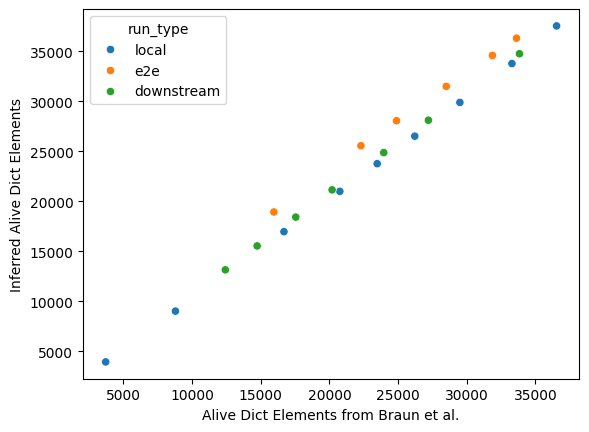

In [125]:
g = sns.scatterplot(data=df_interest, x="alive_dict_elements", y="active_dict_elements_observed", hue = "run_type")
g.set(xlabel="Alive Dict Elements from Braun et al.", ylabel = "Inferred Alive Dict Elements")


## Plot KL Divergence

### for mean

In [126]:
df_interest["mean_df"] = [get_mean_df(x) for x in df_interest["id"]]

In [127]:
mean_df_all = pd.concat(list(df_interest["mean_df"])).reset_index()

In [128]:
mean_df_all["run_type"] = df_interest["run_type"]
mean_df_all["L0"] = df_interest["L0"]

col_names = [f'{direction_type}_feature_length_{length}_kl' for length in range(1, 211, 10) for direction_type in ["alive", "active", "dead"]]
mean_df_melt = pd.melt(mean_df_all, id_vars=['reconstruction_error', 'L0', 'run_type'], value_vars=col_names, ignore_index=False)
mean_df_melt["metric"] = "KL"

# col_names = [f'error_length_{length}_loss' for length in range(1, 211, 10)]
# mean_df_melt_loss = pd.melt(mean_df, id_vars=['reconstruction_error', 'L0', 'type'], value_vars=col_names, ignore_index=False)
# mean_df_melt_loss["metric"] = "Loss"

# mean_df_melt = pd.concat([mean_df_melt_kl, mean_df_melt_loss])
mean_df_melt["perturbation_length"] = mean_df_melt["variable"].str.split("_", expand = True)[3].astype(int)
mean_df_melt["perturbation_type"] = mean_df_melt["variable"].str.split("_", expand = True)[0]

mean_df_melt["L0"] = [f"{x:.1f}" for x in mean_df_melt["L0"]]
mean_df_melt["L0"] = mean_df_melt["L0"].astype(float)

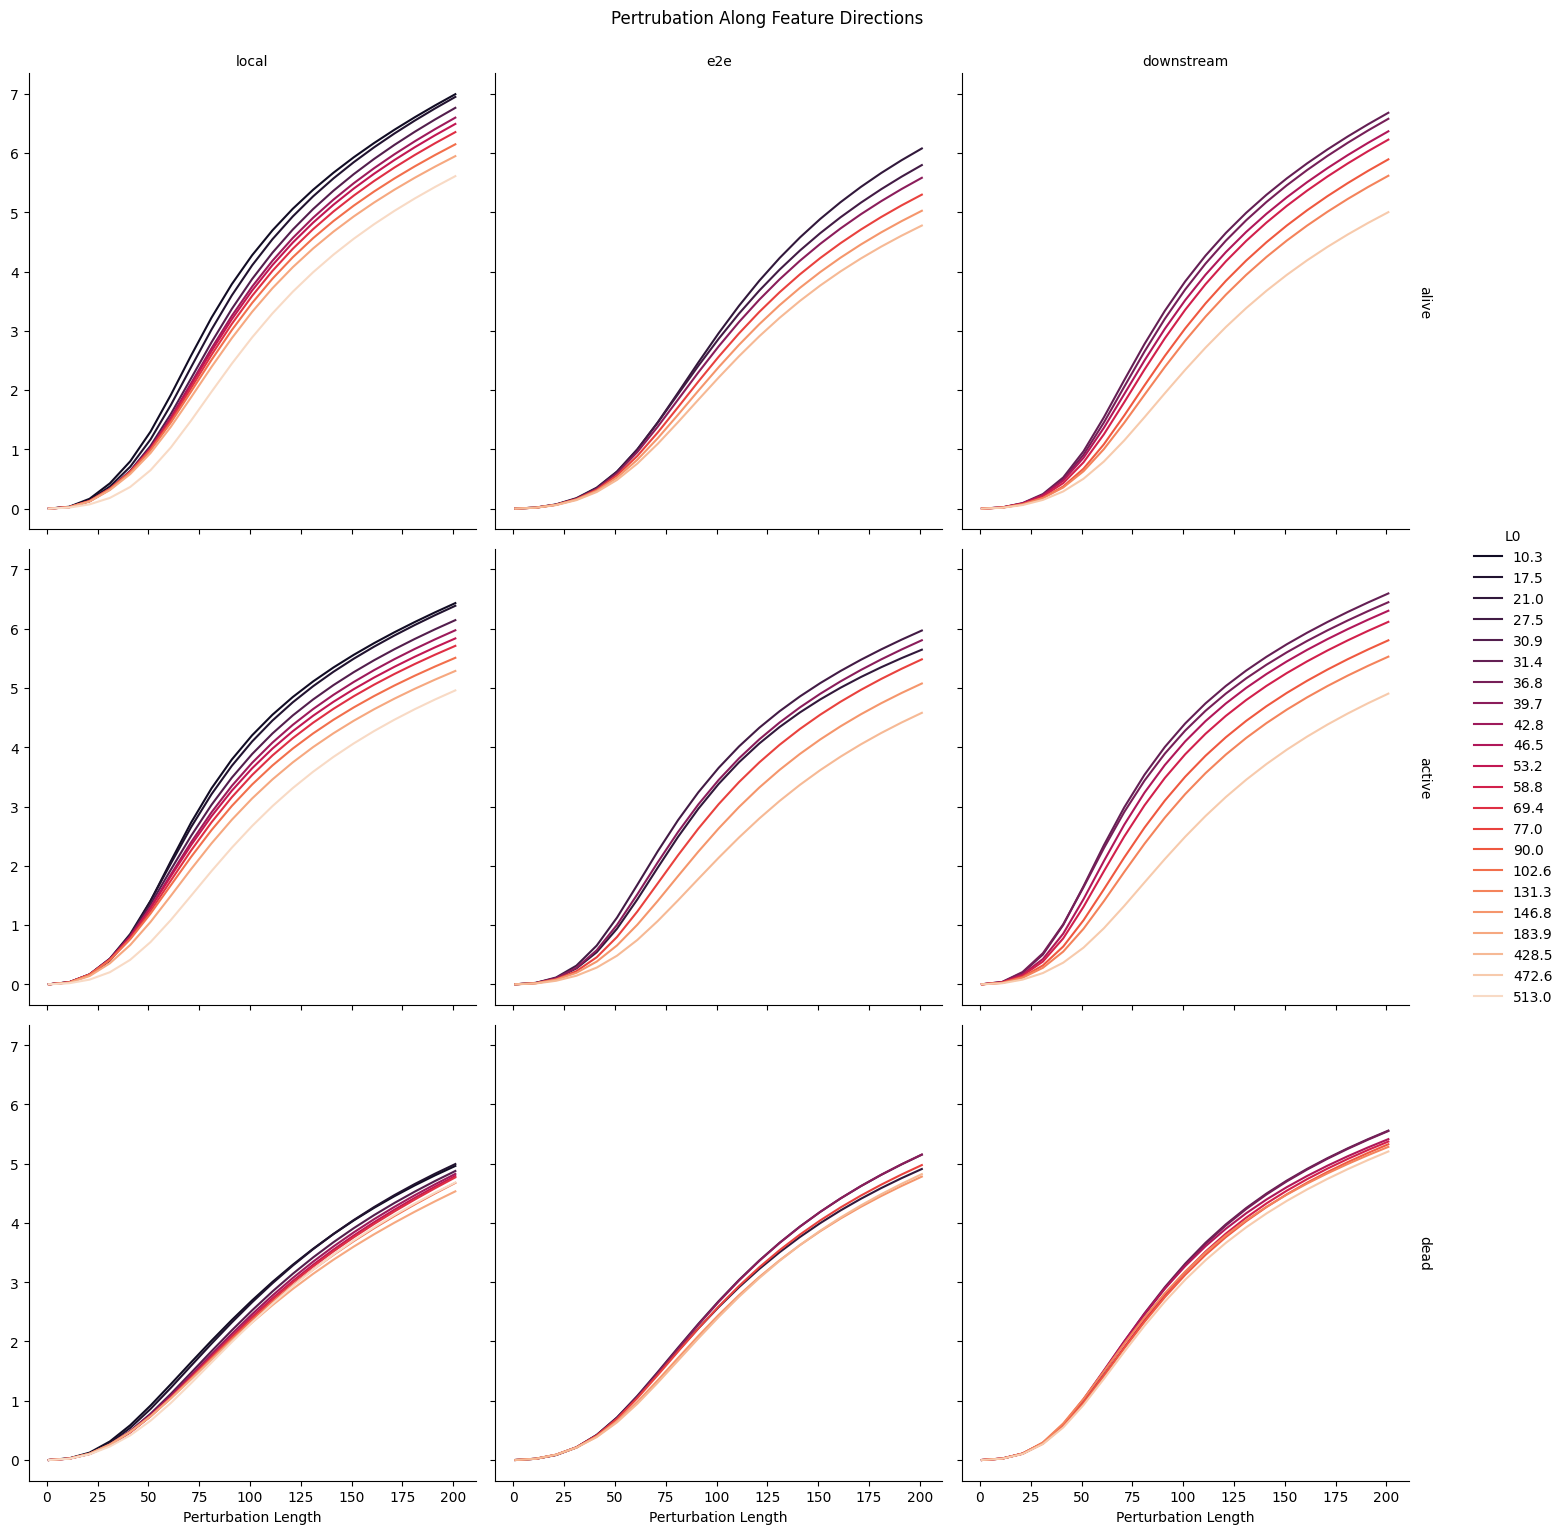

In [129]:
# sns.set_theme(style="darkgrid")

mean_df_melt_plot = mean_df_melt.copy()
# mean_df_melt_plot = mean_df_melt[(mean_df_melt["L0"] >= 30)]

g = sns.FacetGrid(mean_df_melt_plot, row = "perturbation_type", col="run_type", height=5, margin_titles=True, hue = "L0", 
                  palette = 'rocket')

g.map(sns.lineplot, "perturbation_length", "value")

g.set_titles(col_template="{col_name}", row_template="{row_name}")

g.fig.suptitle(f'Pertrubation Along Feature Directions', y = 1.02)

g.set(xlabel="Perturbation Length", ylabel = None)
g.add_legend()

# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

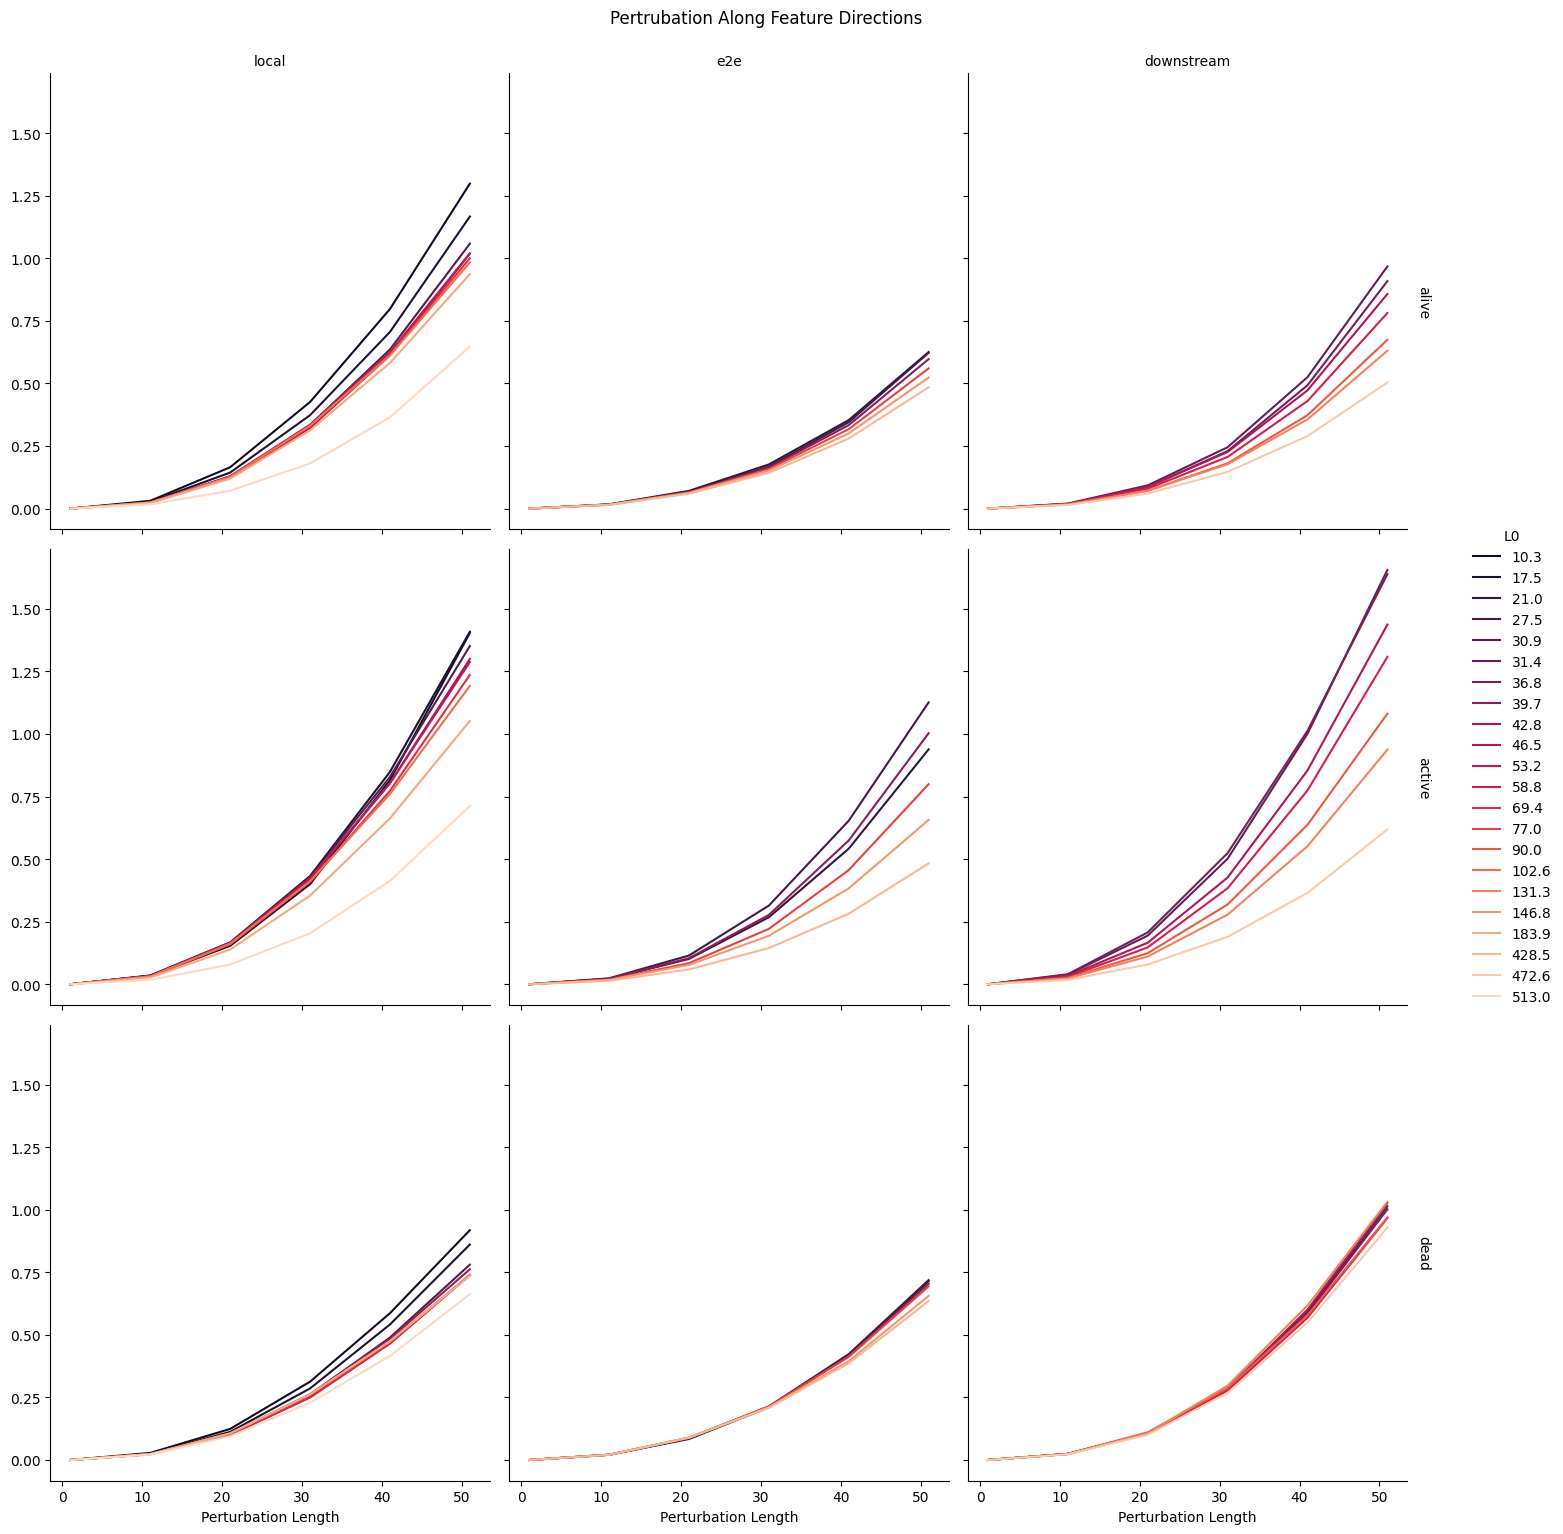

In [130]:
# sns.set_theme(style="darkgrid")

mean_df_melt_plot = mean_df_melt[(mean_df_melt["perturbation_length"] <= 51)]


g = sns.FacetGrid(mean_df_melt_plot, row = "perturbation_type", col="run_type", height=5, margin_titles=True, hue = "L0", 
                  palette = 'rocket')

g.map(sns.lineplot, "perturbation_length", "value")

g.set_titles(col_template="{col_name}", row_template="{row_name}")

g.fig.suptitle(f'Pertrubation Along Feature Directions', y = 1.02)

g.set(xlabel="Perturbation Length", ylabel = None)
g.add_legend()


# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

### Plot median

Median looks roughly similar to the mean

In [ ]:
df_interest["median_df"] = [get_median_df(x) for x in df_interest["id"]]

In [105]:
median_df_all = pd.concat(list(df_interest["median_df"])).reset_index()

In [106]:
median_df_all["run_type"] = df_interest["run_type"]
median_df_all["L0"] = df_interest["L0"]

col_names = [f'{direction_type}_feature_length_{length}_kl' for length in range(1, 211, 10) for direction_type in ["alive", "active", "dead"]]
median_df_melt = pd.melt(median_df_all, id_vars=['reconstruction_error', 'L0', 'run_type'], value_vars=col_names, ignore_index=False)
median_df_melt["metric"] = "KL"

median_df_melt["perturbation_length"] = median_df_melt["variable"].str.split("_", expand = True)[3].astype(int)
median_df_melt["perturbation_type"] = median_df_melt["variable"].str.split("_", expand = True)[0]

median_df_melt["L0"] = [f"{x:.1f}" for x in median_df_melt["L0"]]
median_df_melt["L0"] = median_df_melt["L0"].astype(float)

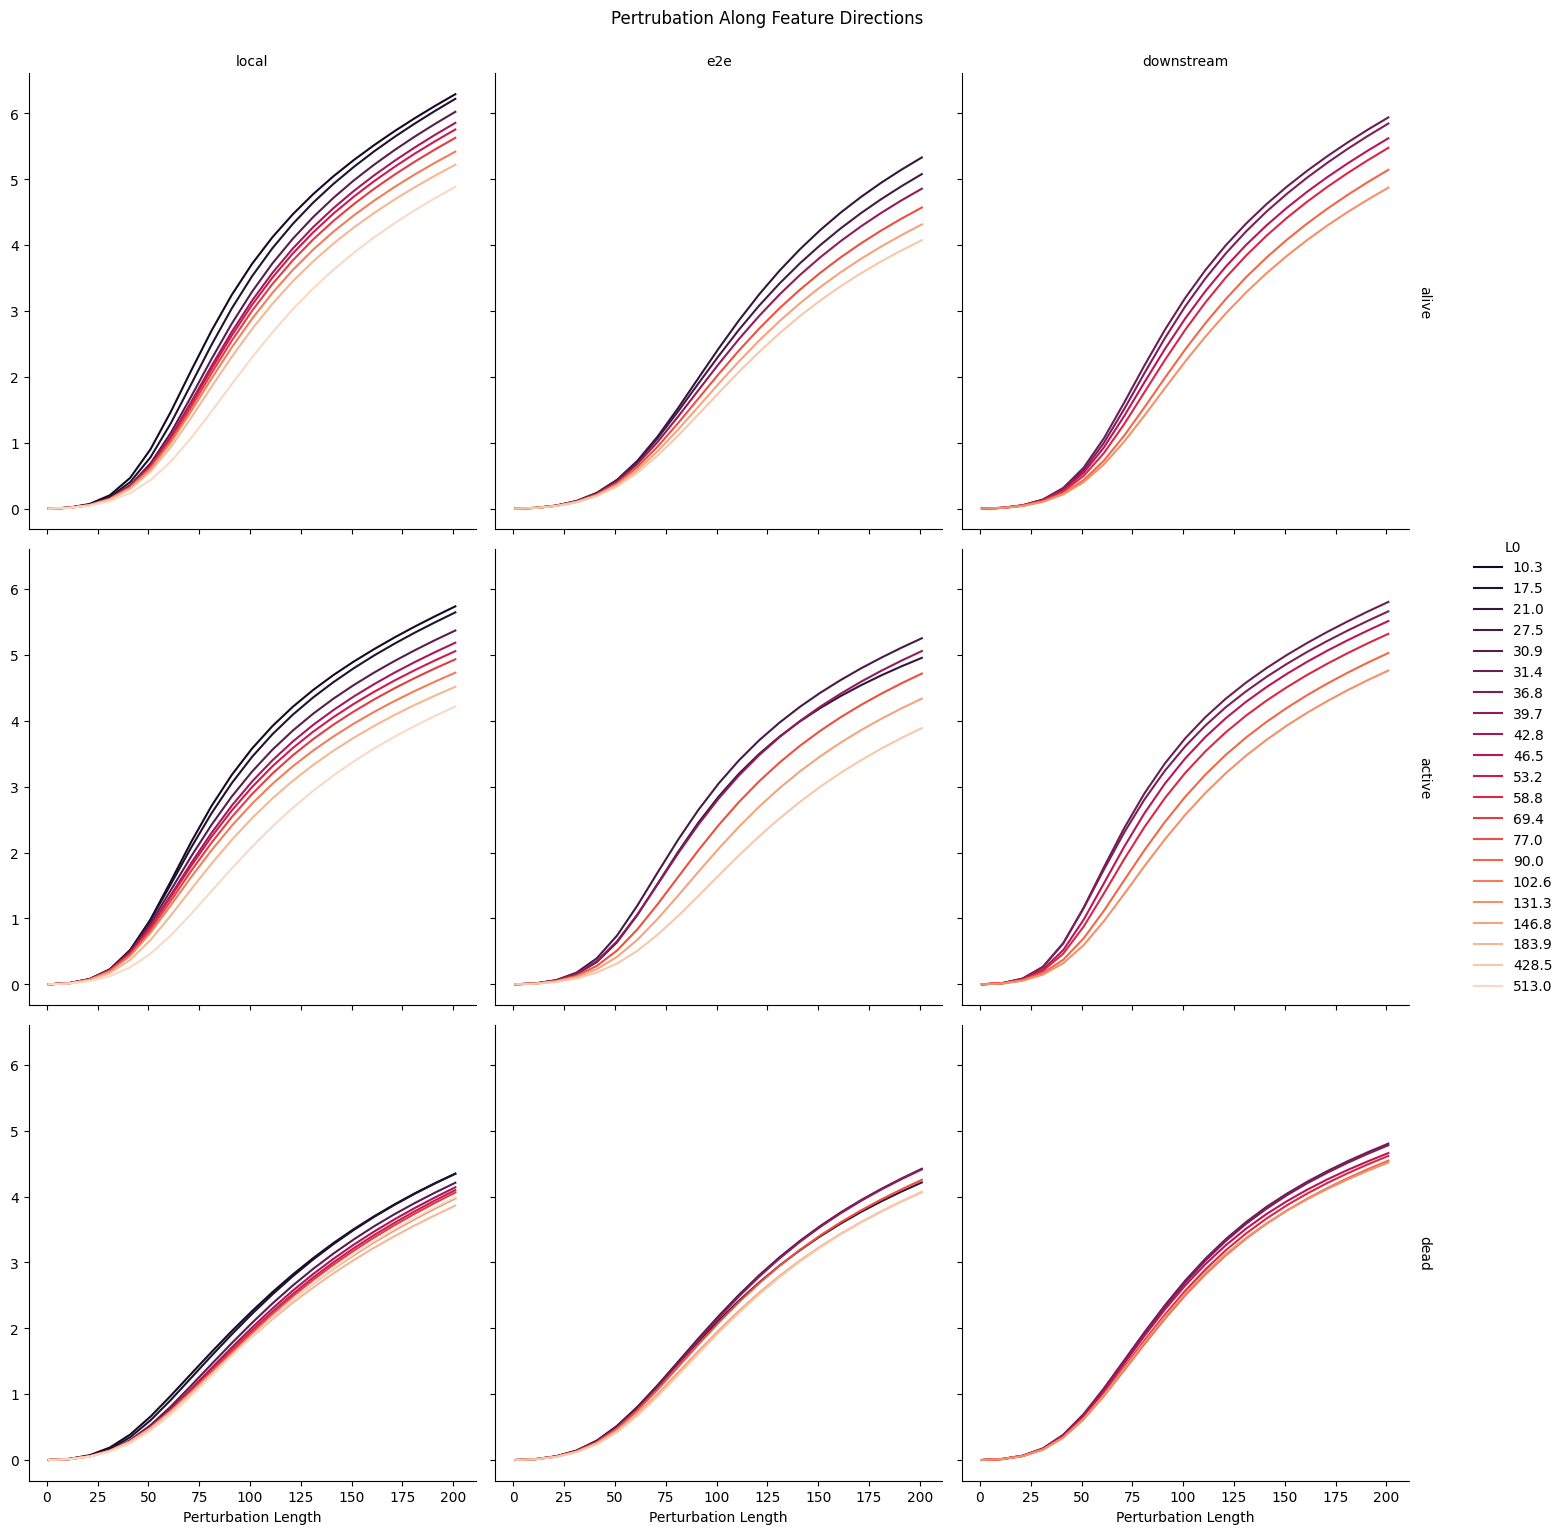

In [108]:
# sns.set_theme(style="darkgrid")

median_df_melt_plot = median_df_melt.copy()
# mean_df_melt_plot = mean_df_melt[(mean_df_melt["L0"] >= 30)]

g = sns.FacetGrid(median_df_melt_plot, row = "perturbation_type", col="run_type", height=5, margin_titles=True, hue = "L0", 
                  palette = 'rocket')

g.map(sns.lineplot, "perturbation_length", "value")

g.set_titles(col_template="{col_name}", row_template="{row_name}")

g.fig.suptitle(f'Pertrubation Along Feature Directions', y = 1.02)

g.set(xlabel="Perturbation Length", ylabel = None)
g.add_legend()

# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

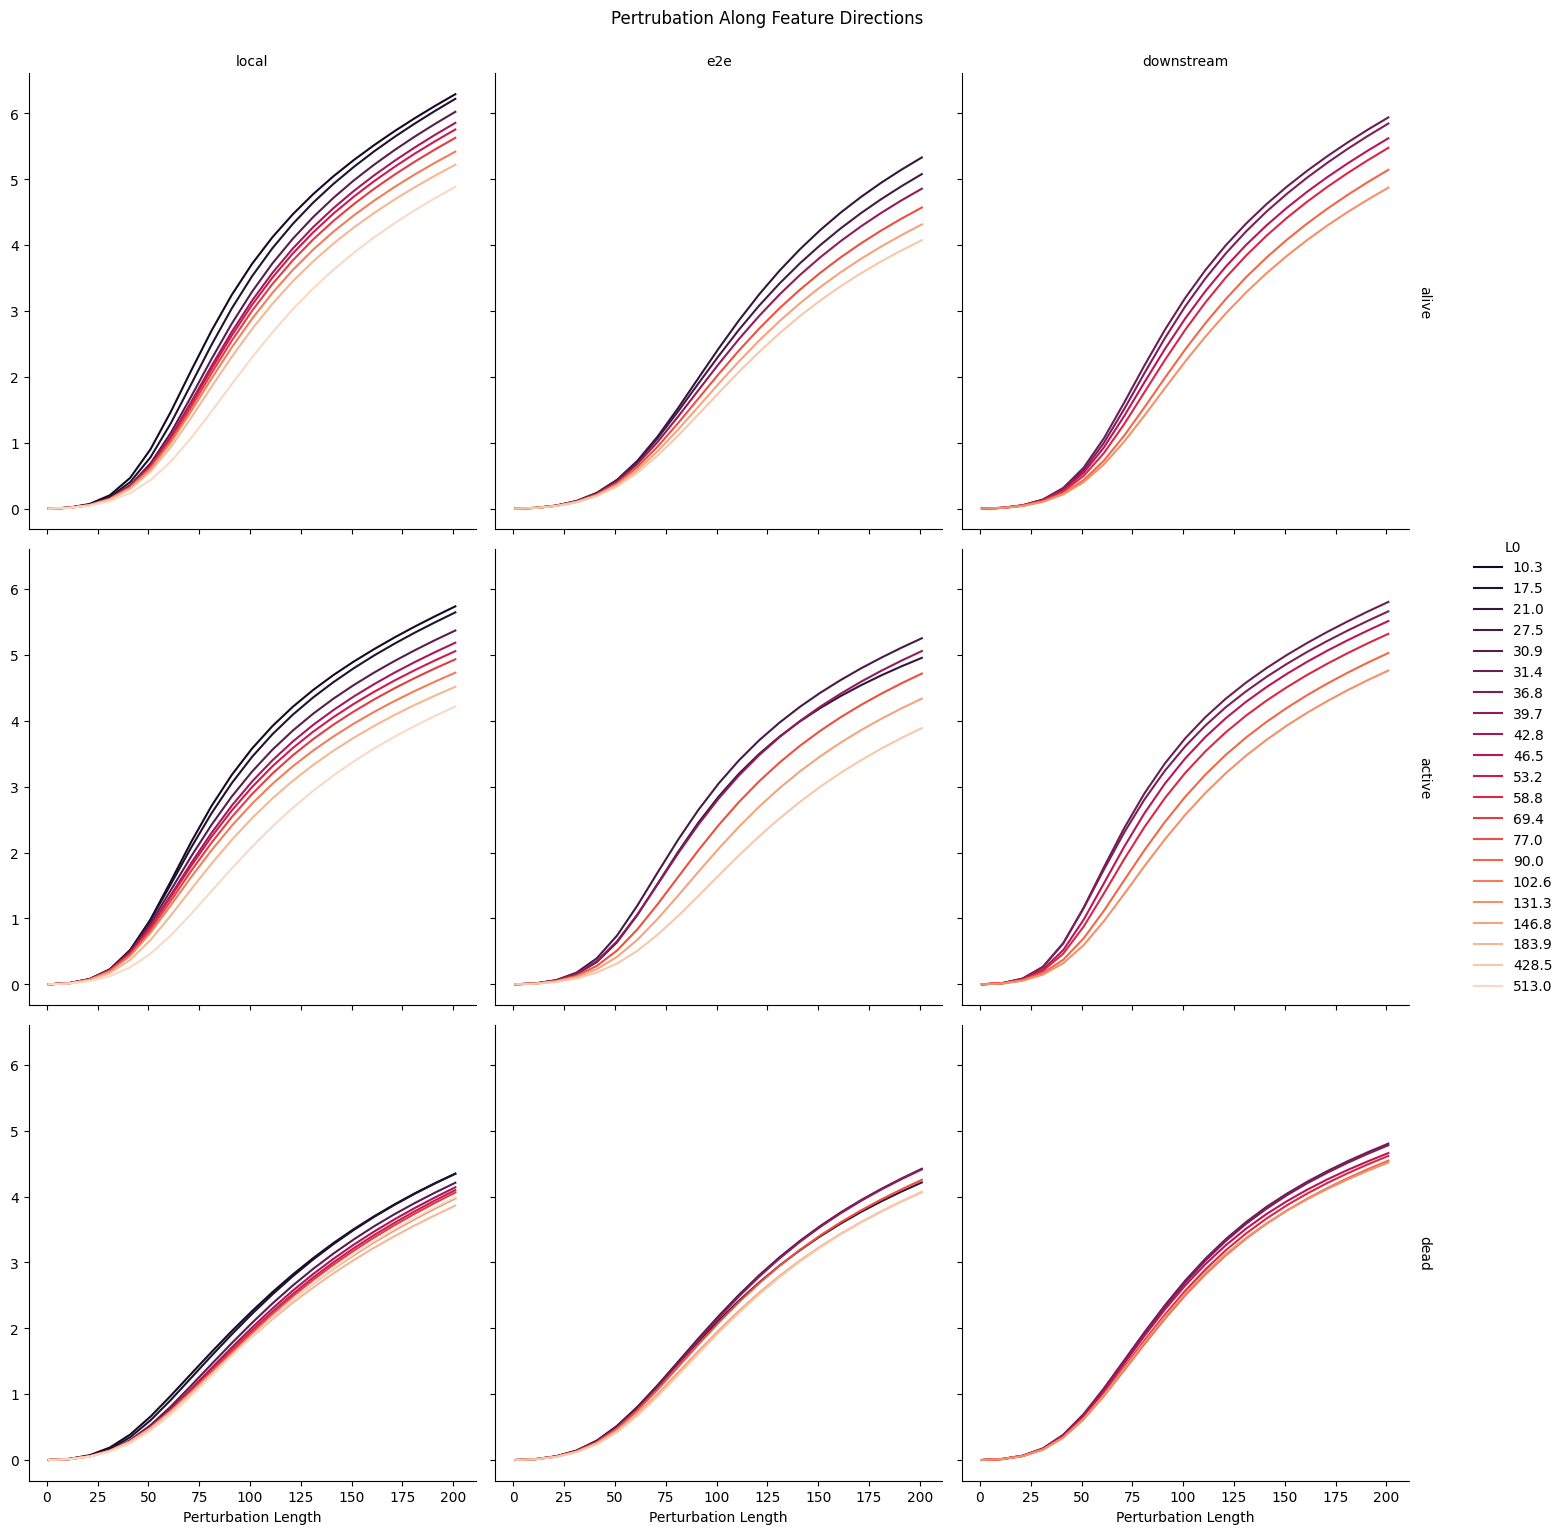

In [109]:
# sns.set_theme(style="darkgrid")

mean_df_melt_plot = median_df_melt[(median_df_melt["perturbation_length"] <= 51)]

# mean_df_melt_plot = mean_df_melt[(mean_df_melt["L0"] >= 30)]

g = sns.FacetGrid(median_df_melt_plot, row = "perturbation_type", col="run_type", height=5, margin_titles=True, hue = "L0", 
                  palette = 'rocket')

g.map(sns.lineplot, "perturbation_length", "value")

g.set_titles(col_template="{col_name}", row_template="{row_name}")

g.fig.suptitle(f'Pertrubation Along Feature Directions', y = 1.02)

g.set(xlabel="Perturbation Length", ylabel = None)
g.add_legend()

# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

# Plot For A SAE Local Model

In [3]:
directory = "/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/results/feature_extrapolation/gpt2_resid_pre/"
model_id = "uiwt81f1"
df = pd.read_csv(directory + f"e2e_{model_id}_layer_6_seed_23_batchsize_1_pos_all.csv")
# df = df[df["position"] != 0]

In [31]:
col_names = [f'{feature_type}_feature_length_{length}_kl' for feature_type in ["alive", "active", "dead"] for length in range(1, 211, 10)]
col_names_201 = [f'{feature_type}_feature_length_{length}_kl' for feature_type in ["alive", "active", "dead"] for length in [201]]


## Plot Mean

In [4]:
mean_df = pd.DataFrame(df.mean(axis=0)).T
mean_df_melt = pd.melt(mean_df, id_vars=['reconstruction_error'], value_vars=col_names, ignore_index=False)
mean_df_melt["error_length"] = mean_df_melt["variable"].str.split("_", expand = True)[3].astype(int)
mean_df_melt["error_direction"] = mean_df_melt["variable"].str.split("_", expand = True)[0]

<Axes: xlabel='error_length', ylabel='value'>

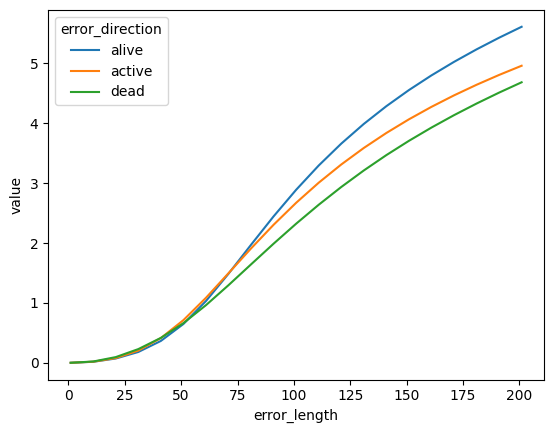

In [9]:
## for e2e SAE 4d5ksz89

sns.lineplot(data=mean_df_melt, x="error_length", y="value", hue = "error_direction")


<Axes: xlabel='error_length', ylabel='value'>

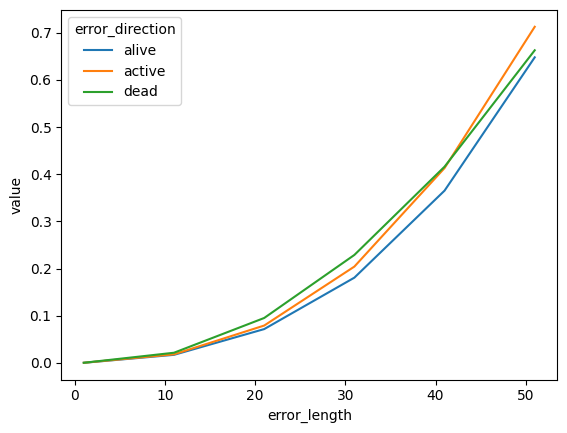

In [11]:
mean_df_melt_plot = mean_df_melt[(mean_df_melt["error_length"] <= 51)]

sns.lineplot(data=mean_df_melt_plot, x="error_length", y="value", hue = "error_direction")


## Plot Var

In [15]:
var_df = pd.DataFrame(df.var(axis=0)).T
var_df_melt = pd.melt(var_df, id_vars=['reconstruction_error'], value_vars=col_names, ignore_index=False)
var_df_melt["error_length"] = var_df_melt["variable"].str.split("_", expand = True)[3].astype(int)
var_df_melt["error_direction"] = var_df_melt["variable"].str.split("_", expand = True)[0]

<Axes: xlabel='error_length', ylabel='value'>

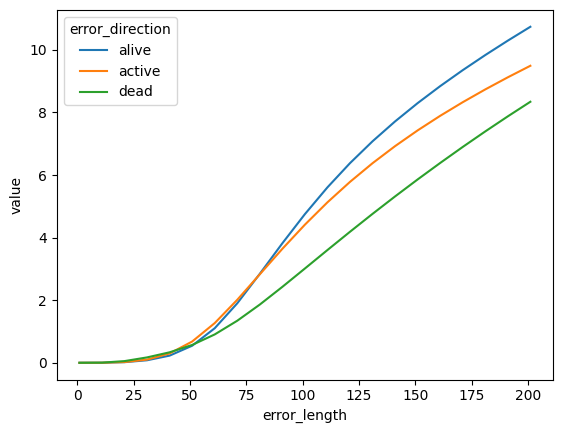

In [18]:
## for e2e SAE 4d5ksz89

sns.lineplot(data=var_df_melt, x="error_length", y="value", hue = "error_direction")


<Axes: xlabel='error_length', ylabel='value'>

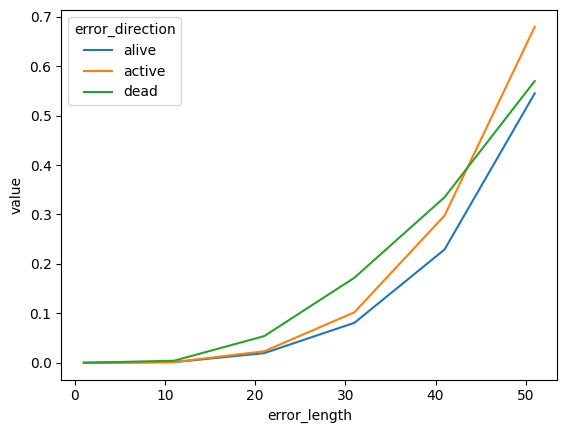

In [19]:
var_df_melt_plot = var_df_melt[(var_df_melt["error_length"] <= 51)]

sns.lineplot(data=var_df_melt_plot, x="error_length", y="value", hue = "error_direction")


## Plot some samples

In [96]:
for i in range(9):
    df_sample = df.sample(n = 7)
    df_sample_melt = pd.melt(df_sample, id_vars=['token'], value_vars=col_names, ignore_index=False)
    df_sample_melt["perturb_length"] = df_sample_melt["variable"].str.split("_", expand = True)[3].astype(int)
    df_sample_melt["perturb_direction"] = df_sample_melt["variable"].str.split("_", expand = True)[0]
    df_sample_melt["index"] = df_sample_melt.index
    df_sample_melt["iteration"] = i

    if i == 0:
        df_sample_melt_all = df_sample_melt.copy()
    else:
        df_sample_melt_all = pd.concat([df_sample_melt_all, df_sample_melt])

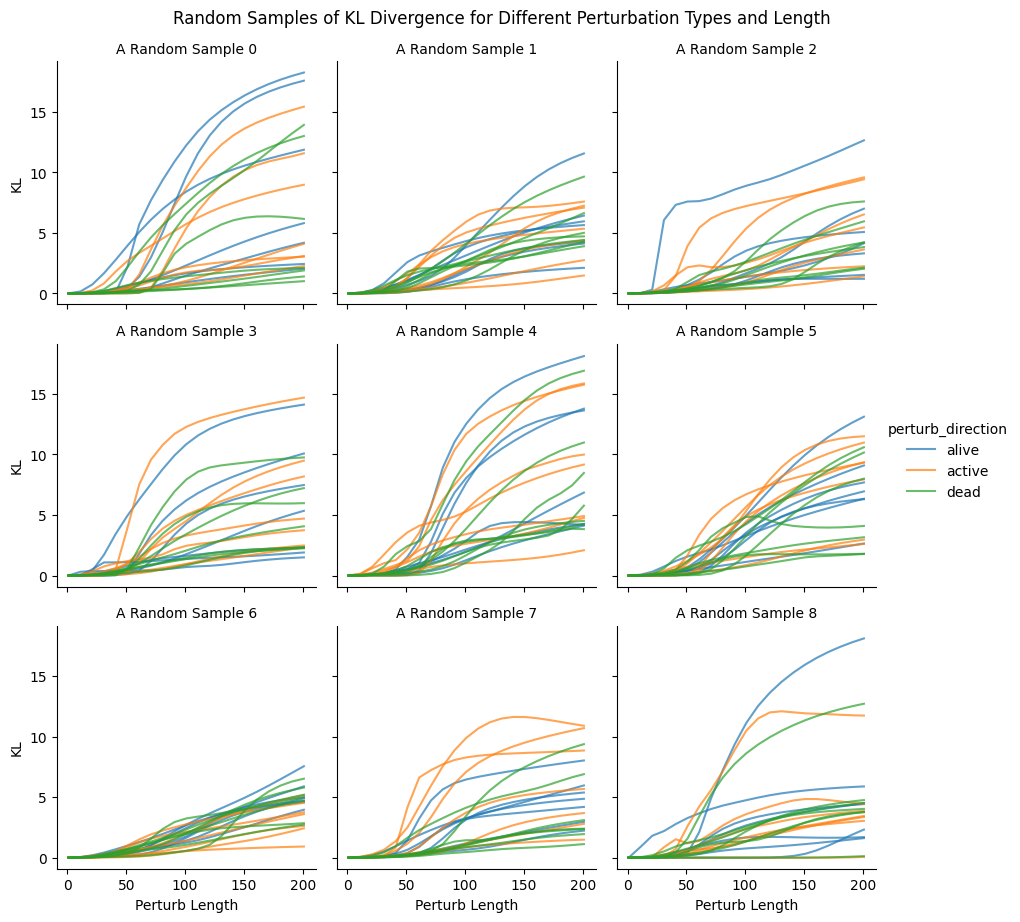

In [97]:
# g = sns.FacetGrid(df_sample_melt_all, col="iteration", col_wrap = 3, height=5, margin_titles=True, hue = "perturb_direction")

g = sns.FacetGrid(df_sample_melt_all, col="iteration", col_wrap = 3, hue = "perturb_direction")

g.map_dataframe(sns.lineplot, x='perturb_length', y='value', units='index', estimator=None, alpha = 0.7)
g.set_titles(col_template="A Random Sample {col_name}")

g.fig.suptitle(f'Random Samples of KL Divergence for Different Perturbation Types and Length', y = 1.02)

g.set(xlabel="Perturb Length", ylabel = "KL")
g.add_legend()

# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

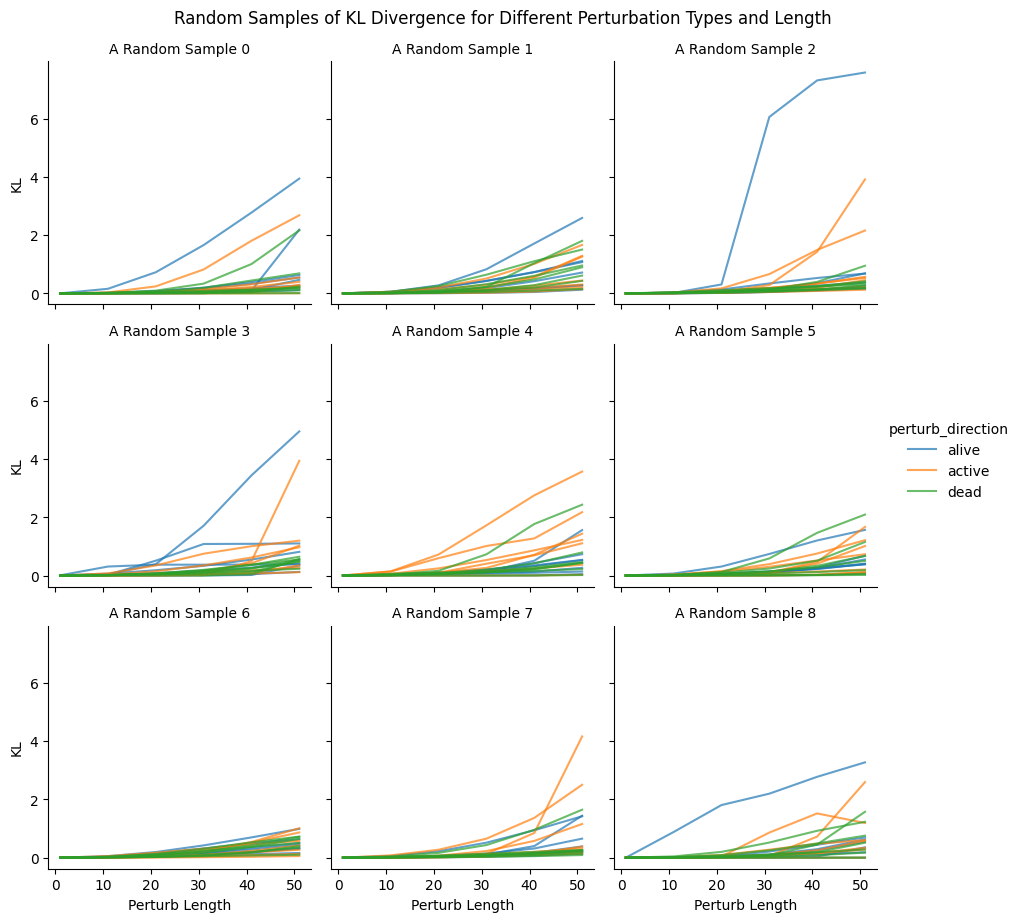

In [98]:
df_sample_melt_all_plot = df_sample_melt_all[df_sample_melt_all["perturb_length"] <= 51]
g = sns.FacetGrid(df_sample_melt_all_plot, col="iteration", col_wrap = 3, hue = "perturb_direction")

g.map_dataframe(sns.lineplot, x='perturb_length', y='value', units='index', estimator=None, alpha = 0.7)
g.set_titles(col_template="A Random Sample {col_name}")

g.fig.suptitle(f'Random Samples of KL Divergence for Different Perturbation Types and Length', y = 1.02)

g.set(xlabel="Perturb Length", ylabel = "KL")
g.add_legend()

# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

In [110]:
df.iloc[723081]

token                          398.000000
position                        70.000000
loss                             0.002730
alive_feature_length_1_loss      0.002687
alive_feature_length_1_kl        0.000001
                                  ...    
sae_l1                         368.355470
reconstruction_error            16.236292
norm                            81.600490
sae_norm                        77.902530
cos                              0.980341
Name: 723081, Length: 135, dtype: float64

In [111]:
df_sample_melt_all_2[(df_sample_melt_all_2["iteration"] == 0) & (df_sample_melt_all_2["perturb_length"] <= 51)
                    & (df_sample_melt_all_2["index"] == 723081)].sort_values("value")

,token,variable,value,perturb_length,perturb_direction,index,iteration
723081,398,alive_feature_length_1_kl,0.000001,1,alive,723081,0
723081,398,dead_feature_length_1_kl,0.000002,1,dead,723081,0
723081,398,active_feature_length_1_kl,0.000004,1,active,723081,0
723081,398,dead_feature_length_11_kl,0.000199,11,dead,723081,0
723081,398,alive_feature_length_11_kl,0.000530,11,alive,723081,0
723081,398,dead_feature_length_21_kl,0.000772,21,dead,723081,0
723081,398,active_feature_length_11_kl,0.002073,11,active,723081,0
723081,398,dead_feature_length_31_kl,0.002523,31,dead,723081,0
723081,398,alive_feature_length_21_kl,0.010280,21,alive,723081,0
723081,398,dead_feature_length_41_kl,0.011056,41,dead,723081,0


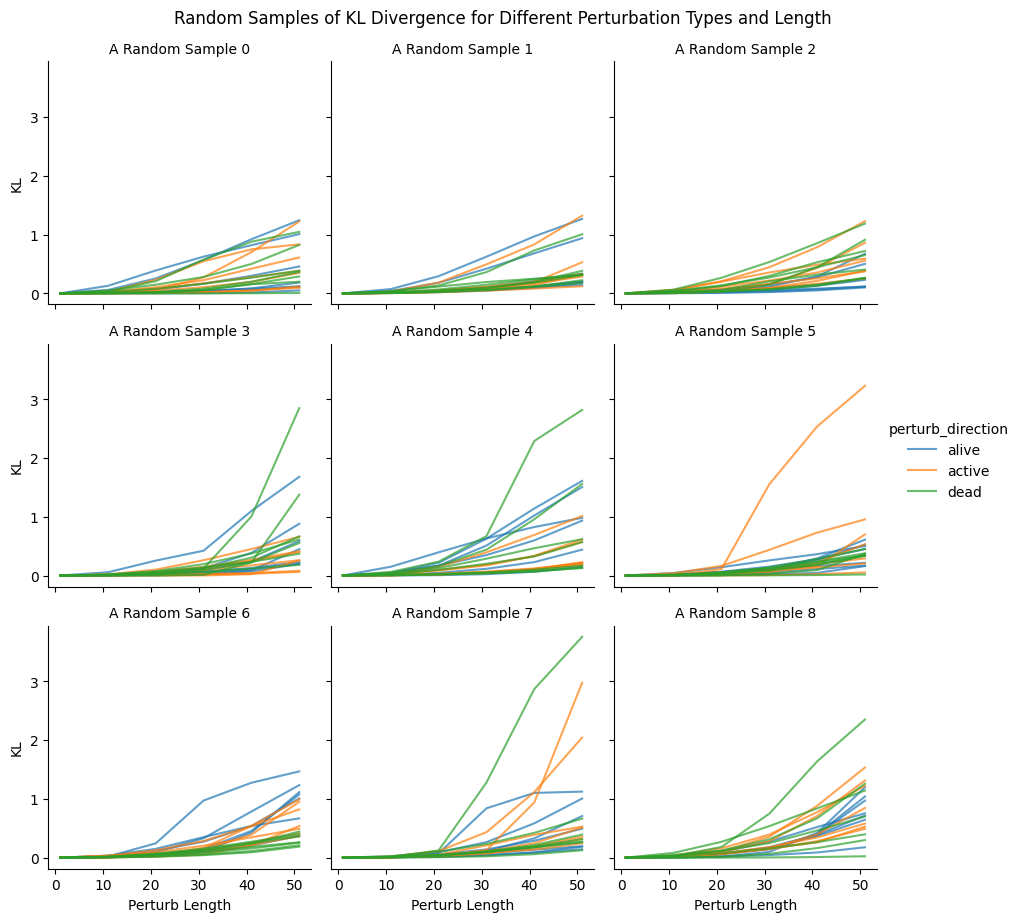

In [113]:
for i in range(9):
    df_sample = df.sample(n = 7)
    df_sample_melt = pd.melt(df_sample, id_vars=['token'], value_vars=col_names, ignore_index=False)
    df_sample_melt["perturb_length"] = df_sample_melt["variable"].str.split("_", expand = True)[3].astype(int)
    df_sample_melt["perturb_direction"] = df_sample_melt["variable"].str.split("_", expand = True)[0]
    df_sample_melt["index"] = df_sample_melt.index
    df_sample_melt["iteration"] = i

    if i == 0:
        df_sample_melt_all_2 = df_sample_melt.copy()
    else:
        df_sample_melt_all_2 = pd.concat([df_sample_melt_all_2, df_sample_melt])

df_sample_melt_all_plot = df_sample_melt_all_2[df_sample_melt_all_2["perturb_length"] <= 51]
g = sns.FacetGrid(df_sample_melt_all_plot, col="iteration", col_wrap = 3, hue = "perturb_direction")

g.map_dataframe(sns.lineplot, x='perturb_length', y='value', units='index', estimator=None, alpha = 0.7)
g.set_titles(col_template="A Random Sample {col_name}")

g.fig.suptitle(f'Random Samples of KL Divergence for Different Perturbation Types and Length', y = 1.02)

g.set(xlabel="Perturb Length", ylabel = "KL")
g.add_legend()

# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

<Axes: xlabel='perturb_length', ylabel='value'>

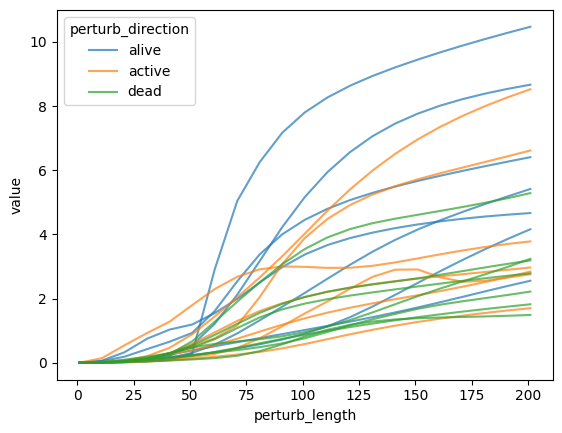

In [101]:
sns.lineplot(data=df_sample_melt, x="perturb_length", y="value", hue = "perturb_direction", estimator = None, units = "index", alpha = 0.7)

<Axes: xlabel='perturb_length', ylabel='value'>

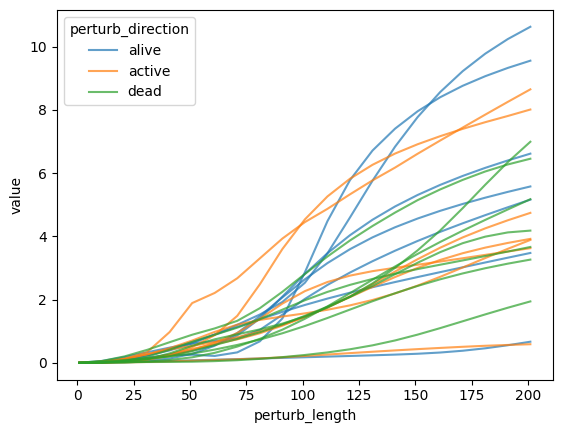

In [69]:
sns.lineplot(data=df_sample_melt, x="perturb_length", y="value", hue = "perturb_direction", estimator = None, units = "index", alpha = 0.7)


## Plot Distribution of Perturb Length Slice

In [34]:
df_melt = pd.melt(df, id_vars=['token'], value_vars=col_names_201, ignore_index=False)
df_melt["error_direction"] = df_melt["variable"].str.split("_", expand = True)[0]


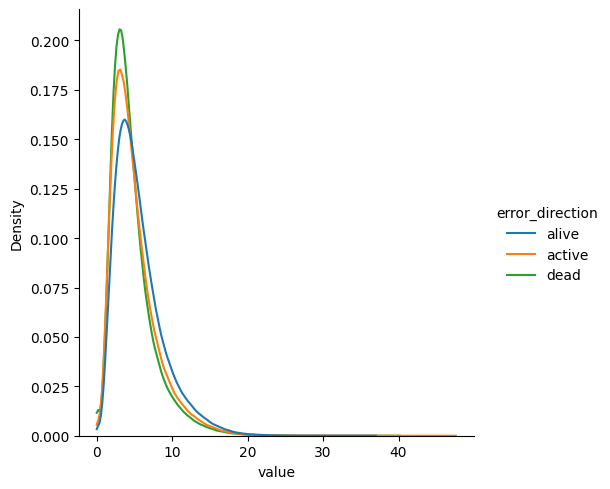

In [39]:
error_length

sns.displot(df_melt, x="value", hue="error_direction", common_norm=False, kind = "kde", cut=0)


In [41]:
df_melt

,token,variable,value,error_direction
0,50256,alive_feature_length_201_kl,2.472692,alive
1,17402,alive_feature_length_201_kl,4.810239,alive
2,22038,alive_feature_length_201_kl,5.871099,alive
3,4870,alive_feature_length_201_kl,6.501952,alive
4,7806,alive_feature_length_201_kl,14.109979,alive
...,...,...,...,...
2031995,3936,dead_feature_length_201_kl,1.456942,dead
2031996,329,dead_feature_length_201_kl,2.478977,dead
2031997,257,dead_feature_length_201_kl,5.249169,dead
2031998,1178,dead_feature_length_201_kl,5.466972,dead


Text(0.5, 0.98, 'Perturb Length: 21')

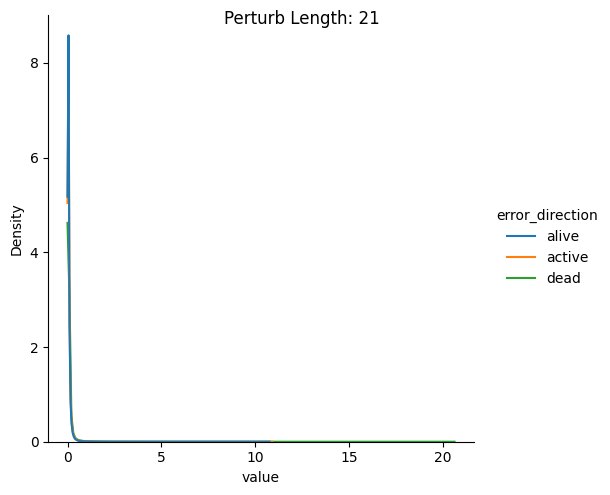

In [42]:
error_length = 21
col_names_value = [f'{feature_type}_feature_length_{length}_kl' for feature_type in ["alive", "active", "dead"] for length in [error_length]]
df_melt = pd.melt(df, id_vars=['token'], value_vars=col_names_value, ignore_index=False)
df_melt["error_direction"] = df_melt["variable"].str.split("_", expand = True)[0]

g = sns.displot(df_melt, x="value", hue="error_direction", common_norm=False, kind = "kde", cut=0)
g.fig.suptitle(f'Perturb Length: {error_length}')


In [13]:
df_126 = df[df["position"] == 126]
df_20 = df[df["position"] == 20]

In [16]:
df_melt

,token,variable,value,error_length,error_direction
20,290,alive_feature_length_1_kl,0.000099,1,alive
147,351,alive_feature_length_1_kl,0.000069,1,alive
274,13,alive_feature_length_1_kl,0.000063,1,alive
401,1975,alive_feature_length_1_kl,0.000144,1,alive
528,3173,alive_feature_length_1_kl,0.000074,1,alive
...,...,...,...,...,...
2031385,2840,dead_feature_length_201_kl,9.236586,201,dead
2031512,860,dead_feature_length_201_kl,4.579468,201,dead
2031639,3347,dead_feature_length_201_kl,3.763716,201,dead
2031766,198,dead_feature_length_201_kl,0.738012,201,dead


In [23]:
df_melt = pd.melt(df_126, id_vars=['token'], value_vars=col_names, ignore_index=False)
df_melt["error_length"] = df_melt["variable"].str.split("_", expand = True)[3].astype(int)
df_melt["error_direction"] = df_melt["variable"].str.split("_", expand = True)[0]

<Axes: xlabel='error_length', ylabel='value'>

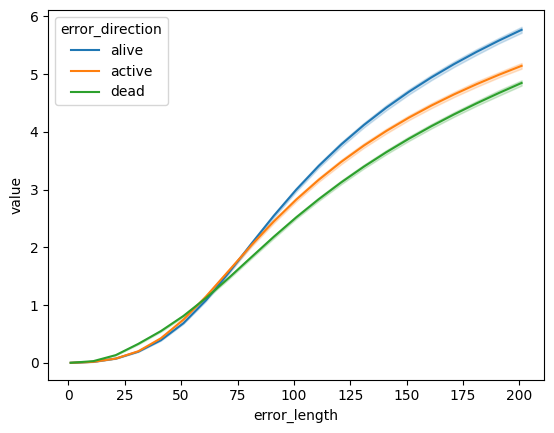

In [24]:
## for e2e SAE 4d5ksz89

sns.lineplot(data=df_melt, x="error_length", y="value", hue="error_direction")

In [20]:
df_melt[df_melt["token"] == 290]

,token,variable,value,error_length,error_direction
20,290,alive_feature_length_1_kl,0.000099,1,alive
3703,290,alive_feature_length_1_kl,0.000097,1,alive
22245,290,alive_feature_length_1_kl,0.000059,1,alive
32151,290,alive_feature_length_1_kl,0.000148,1,alive
34818,290,alive_feature_length_1_kl,0.000067,1,alive
...,...,...,...,...,...
2004715,290,dead_feature_length_201_kl,4.036641,201,dead
2017542,290,dead_feature_length_201_kl,5.421787,201,dead
2024146,290,dead_feature_length_201_kl,5.424740,201,dead
2027575,290,dead_feature_length_201_kl,3.599079,201,dead
